## Logistic Regression Notebook

This notebook builds and evaluates a Logistic Regression classifier for the Adult Income dataset, predicting whether a person earns more than $50K. It covers data loading, exploratory visualizations, structured preprocessing (numeric scaling and categorical encoding), model training, standard evaluation metrics, and interpretation of learned coefficients.

In [1]:
# Centralized imports for data processing, modeling, and visualization.
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bokeh.io import output_notebook
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

from utils.evaluation_utils import ensure_dir
from utils.modeling_common import build_tabular_preprocess, load_adult_dataframe, split_features_target, split_train_test
from utils.notebook_plotting_utils import plot_confusion_matrix, plot_metrics_bar_chart

output_notebook()

Loading BokehJS ...

## Data Preprocessing

Unlike the text-based Naive Bayes approach, Logistic Regression works with structured numeric and categorical features. Missing values are imputed (numeric via median, categorical via mode), numerics are scaled, and categories are one-hot encoded. Feature names are preserved throughout for interpretability.

In [2]:
# Load Adult dataset and prepare features and target variable.
df = load_adult_dataframe("census+income/adult.data")
X, y = split_features_target(df)

print("Rows:", len(df))
print("Positive class rate:", y.mean())
print(X.head(2))

Rows: 32561
Positive class rate: 0.2408095574460244
   age         workclass  education  education_num      marital_status  \
0   39         State-gov  Bachelors             13       Never-married   
1   50  Self-emp-not-inc  Bachelors             13  Married-civ-spouse   

        occupation   relationship   race   sex  capital_gain  capital_loss  \
0     Adm-clerical  Not-in-family  White  Male          2174             0   
1  Exec-managerial        Husband  White  Male             0             0   

   hours_per_week native_country  
0              40  United-States  
1              13  United-States  


## Model Training

Build a preprocessing pipeline that scales numeric features and one-hot encodes categorical features, then fit a Logistic Regression model with stratified train/test split.

In [3]:
# Define preprocessing pipeline and fit logistic regression.
preprocess = build_tabular_preprocess()

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = split_train_test(
    X,
    y,
    test_size=0.25,
    random_state=11,
)

clf.fit(X_train, y_train)

# Save class predictions and probabilities for downstream evaluation/plots.
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

## Model Evaluation

Report classification metrics (accuracy, confusion matrix, and classification report), visualize precision/recall by class, and export the confusion matrix for cross-model comparison.

In [4]:
# Compute evaluation metrics, visualize precision/recall and confusion matrix heat map, and export confusion matrix.
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Visualize precision and recall from the classification report (same layout as Naive Bayes notebook).
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# Keep only class rows (exclude accuracy/macro avg/weighted avg).
class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

display(metrics_df)

Accuracy: 0.8485444048642673

Confusion matrix:
 [[5747  434]
 [ 799 1161]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      6181
           1       0.73      0.59      0.65      1960

    accuracy                           0.85      8141
   macro avg       0.80      0.76      0.78      8141
weighted avg       0.84      0.85      0.84      8141



,class,precision,recall
0,0,0.877941,0.929785
1,1,0.727900,0.592347


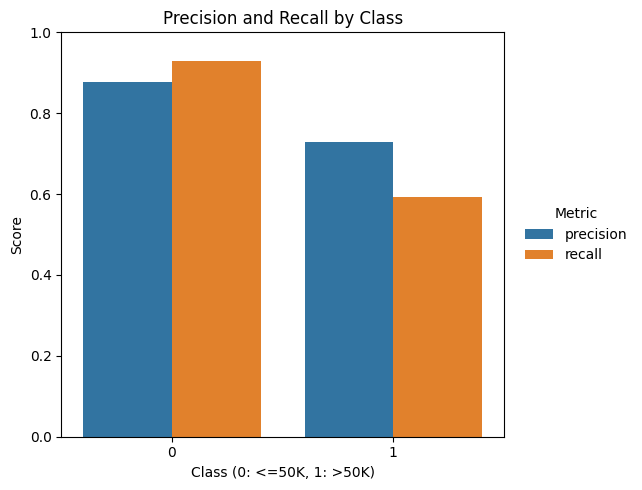

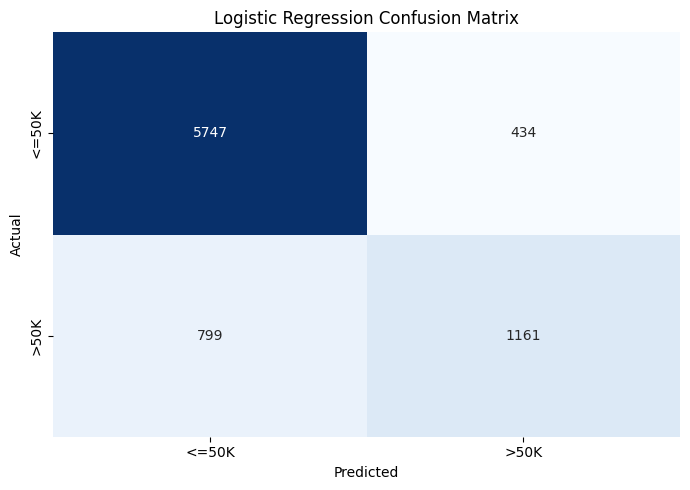

In [5]:
# Visualize precision and recall from the classification report (using shared utility).
plot_metrics_bar_chart(metrics_long)

# Confusion matrix heat map (using shared utility)
plot_confusion_matrix(cm, title="Logistic Regression Confusion Matrix")

In [6]:
# Export matrix and probabilities for cross-model comparison plots.
ensure_dir(Path("exports"))
lr_cm_path = os.path.join("exports", "logistic_regression_confusion_matrix.csv")
np.savetxt(lr_cm_path, cm, fmt="%d", delimiter=",")

lr_probs_path = os.path.join("exports", "logistic_regression_probs.csv")
np.savetxt(lr_probs_path, np.column_stack([y_test.to_numpy(), y_proba]), delimiter=",")

print(f"Saved Logistic Regression confusion matrix to: {lr_cm_path}")
print(f"Saved Logistic Regression probabilities to: {lr_probs_path}")

Saved Logistic Regression confusion matrix to: exports\logistic_regression_confusion_matrix.csv
Saved Logistic Regression probabilities to: exports\logistic_regression_probs.csv


## Feature Importance

Analyze learned logistic regression coefficients to understand which features most strongly predict high income. Positive coefficients favor >50K, negative coefficients favor <=50K.

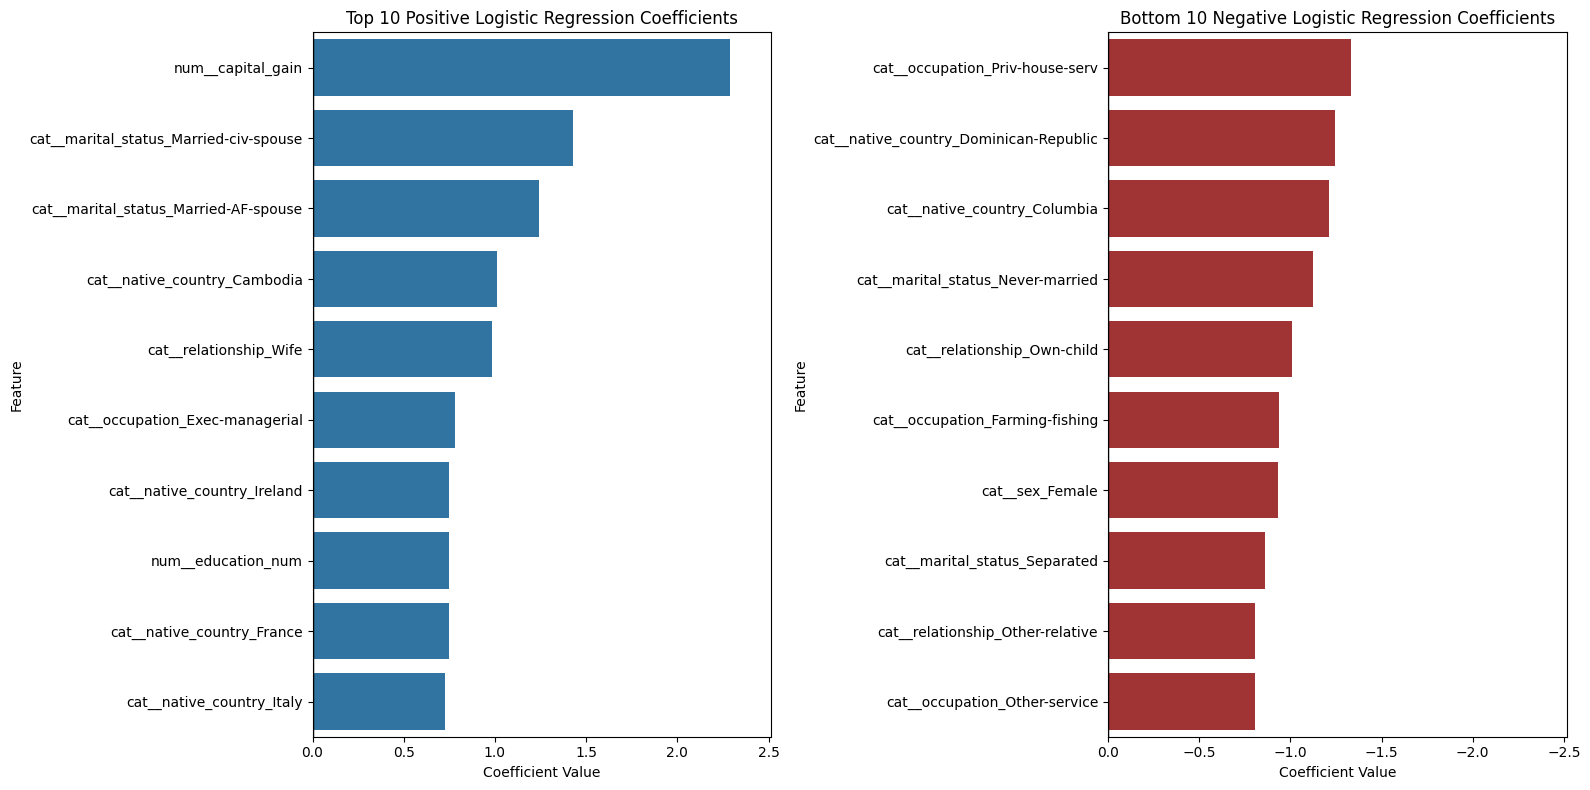

Top 10 positive coefficients (largest absolute value first):


,feature,coefficient
2,num__capital_gain,2.287366
31,cat__marital_status_Married-civ-spouse,1.430048
30,cat__marital_status_Married-AF-spouse,1.244001
63,cat__native_country_Cambodia,1.010787
55,cat__relationship_Wife,0.982314
39,cat__occupation_Exec-managerial,0.781960
82,cat__native_country_Ireland,0.749625
1,num__education_num,0.747529
72,cat__native_country_France,0.747193
83,cat__native_country_Italy,0.723564


Bottom 10 negative coefficients (largest absolute value first):


,feature,coefficient
44,cat__occupation_Priv-house-serv,-1.333422
68,cat__native_country_Dominican-Republic,-1.247551
66,cat__native_country_Columbia,-1.211373
33,cat__marital_status_Never-married,-1.124938
53,cat__relationship_Own-child,-1.009813
40,cat__occupation_Farming-fishing,-0.939025
61,cat__sex_Female,-0.934175
34,cat__marital_status_Separated,-0.861480
52,cat__relationship_Other-relative,-0.807576
43,cat__occupation_Other-service,-0.807063


In [7]:
# Plot top and bottom logistic regression coefficients in separate subplots.
# Pull feature names after preprocessing (numeric + one-hot categorical).
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
coefficients = clf.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

top_n = 10

# Positive and negative groups, each ordered so largest absolute value appears at the top.
top_features = coef_df[coef_df["coefficient"] > 0].nlargest(top_n, "coefficient")
top_features = top_features.sort_values("abs_coefficient", ascending=False)

bottom_features = coef_df[coef_df["coefficient"] < 0].nsmallest(top_n, "coefficient")
bottom_features = bottom_features.sort_values("abs_coefficient", ascending=False)

# Use the same absolute x-limit on both subplots for direct bar-length comparison.
pos_max = top_features["coefficient"].max() if len(top_features) else 0
neg_abs_max = np.abs(bottom_features["coefficient"].min()) if len(bottom_features) else 0
shared_abs_limit = max(pos_max, neg_abs_max) * 1.1 if max(pos_max, neg_abs_max) > 0 else 1

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature",
    order=top_features["feature"],
    color="#1f77b4",
    ax=axes[0]
    )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlim(0, shared_abs_limit)
axes[0].set_title("Top 10 Positive Logistic Regression Coefficients")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

sns.barplot(
    data=bottom_features,
    x="coefficient",
    y="feature",
    order=bottom_features["feature"],
    color="#b22222",
    ax=axes[1]
    )
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(0, -shared_abs_limit)
axes[1].set_title("Bottom 10 Negative Logistic Regression Coefficients")
axes[1].set_xlabel("Coefficient Value")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 positive coefficients (largest absolute value first):")
display(top_features[["feature", "coefficient"]])

print("Bottom 10 negative coefficients (largest absolute value first):")
display(bottom_features[["feature", "coefficient"]])